In [3]:
print('Khai báo thư viện')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Khai báo thư viện thành công')

Khai báo thư viện
Khai báo thư viện thành công


In [5]:
print('Khai báo dữ liệu')

file_path = os.path.join("Data", "Data-processed", "validation.csv")
df_val = pd.read_csv(file_path)
print(f"Shape: {df_val.shape}")

with open(os.path.join("Data", "Data-processed", "train_params.json")) as f:
    params = json.load(f)

print("\nLoaded train_params:")
print(json.dumps(params, indent=2))

Khai báo dữ liệu
Shape: (2880, 18)

Loaded train_params:
{
  "pop_median": 44.0,
  "key_mode": 7,
  "instr_median": 0.00399,
  "loudness_lo": -22.63567,
  "loudness_hi": -2.135,
  "duration_ms_lo": 112843.83251445,
  "duration_ms_hi": 526781.890014451,
  "tempo_lo": 70.97810499999999,
  "tempo_hi": 193.97530250000005
}


In [6]:
missing_df = pd.DataFrame({
    'dtype'        : df_val.dtypes,
    'missing_count': df_val.isnull().sum(),
    'missing_pct'  : (df_val.isnull().sum() / len(df_val) * 100).round(2)
})
print(missing_df[missing_df['missing_count'] > 0])
print(f"\nDuplicate rows: {df_val.duplicated().sum()}")
print(df_val['Class'].value_counts().sort_index())

                    dtype  missing_count  missing_pct
Popularity        float64             58       2.0100
key               float64            342      11.8800
instrumentalness  float64            714      24.7900

Duplicate rows: 0
Class
0     100
1     220
2     204
3      64
4      62
5     231
6     414
7      92
8     297
9     404
10    792
Name: count, dtype: int64


In [7]:
# ── STEP 2: Fix duration mixed units ──────────────────────────────────────
# Giống train — đây là lỗi dữ liệu gốc, không liên quan thông số train

mask_minutes = df_val['duration_in min/ms'] < 100
mask_ms      = df_val['duration_in min/ms'] >= 100

print(f"Values in milliseconds : {mask_ms.sum():,} ({mask_ms.sum()/len(df_val)*100:.1f}%)")
print(f"Values in minutes      : {mask_minutes.sum():,} ({mask_minutes.sum()/len(df_val)*100:.1f}%)")

df_val['duration_in min/ms'] = df_val['duration_in min/ms'].apply(
    lambda x: x * 60 * 1000 if x < 100 else x
)
df_val.rename(columns={'duration_in min/ms': 'duration_ms'}, inplace=True)

print(f"\n✅ duration_ms: min={df_val['duration_ms'].min()/60000:.2f} min, "
      f"max={df_val['duration_ms'].max()/60000:.2f} min")

Values in milliseconds : 2,474 (85.9%)
Values in minutes      : 406 (14.1%)

✅ duration_ms: min=0.93 min, max=14.96 min


In [8]:
# ── STEP 3: Fix loudness dương ─────────────────────────────────────────────
# Giống train — lỗi dữ liệu gốc

print("Loudness > 0 BEFORE fix:")
print(df_val[df_val['loudness'] > 0][['Id', 'loudness']])

df_val.loc[df_val['loudness'] > 0, 'loudness'] = -df_val.loc[df_val['loudness'] > 0, 'loudness']

print(f"\n✅ Loudness range: [{df_val['loudness'].min():.3f}, {df_val['loudness'].max():.3f}]")
print(f"   Values > 0 remaining: {(df_val['loudness'] > 0).sum()}")

Loudness > 0 BEFORE fix:
         Id  loudness
1082   2177    0.8780
1793  11475    0.1190

✅ Loudness range: [-36.214, -0.119]
   Values > 0 remaining: 0


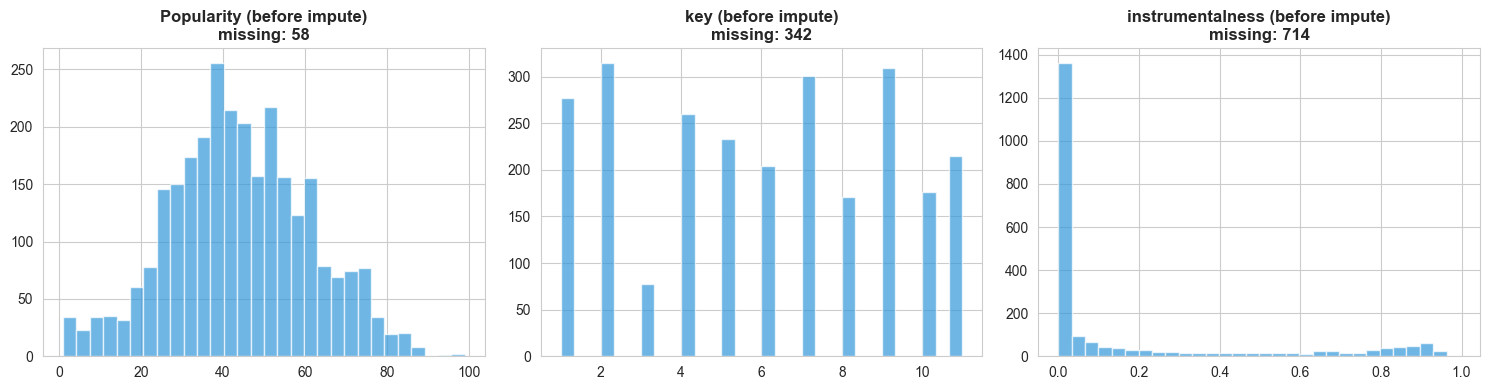

✅ Popularity       — median từ train = 44.0
✅ key              — mode từ train   = 7
✅ instrumentalness — median từ train = 0.003990

Missing values remaining: 0


In [9]:
# ── STEP 4: Impute missing values — DÙNG THÔNG SỐ TỪ TRAIN ────────────────
# ⚠️ KHÔNG tính lại median/mode từ validation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Popularity', 'key', 'instrumentalness']):
    ax.hist(df_val[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (before impute)\nmissing: {df_val[col].isnull().sum()}', fontweight='bold')
plt.tight_layout()
plt.show()

# Fill bằng giá trị từ train
df_val['Popularity']       = df_val['Popularity'].fillna(params['pop_median'])
df_val['key']              = df_val['key'].fillna(params['key_mode'])
df_val['instrumentalness'] = df_val['instrumentalness'].fillna(params['instr_median'])
df_val['key']              = df_val['key'].astype(int)

print(f"✅ Popularity       — median từ train = {params['pop_median']}")
print(f"✅ key              — mode từ train   = {params['key_mode']}")
print(f"✅ instrumentalness — median từ train = {params['instr_median']:.6f}")
print(f"\nMissing values remaining: {df_val.isnull().sum().sum()}")

In [10]:
# ── STEP 5: Winsorize — DÙNG BOUND TỪ TRAIN ───────────────────────────────
# ⚠️ KHÔNG tính lại percentile từ validation

def winsorize_val(df, col, lo, hi):
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(lo, hi)
    affected = ((df[col] == lo) | (df[col] == hi)).sum()
    print(f"{col:20s} before [{before_min:.3f}, {before_max:.3f}] "
          f"→ clipped to [{lo:.3f}, {hi:.3f}] | affected: {affected} rows")
    return df

print("Winsorizing (dùng bound từ train):")
print("-" * 75)
for col in ['loudness', 'duration_ms', 'tempo']:
    df_val = winsorize_val(df_val, col,
                           lo=params[f"{col}_lo"],
                           hi=params[f"{col}_hi"])

Winsorizing (dùng bound từ train):
---------------------------------------------------------------------------
loudness             before [-36.214, -0.119] → clipped to [-22.636, -2.135] | affected: 52 rows
duration_ms          before [56000.000, 897708.000] → clipped to [112843.833, 526781.890] | affected: 44 rows
tempo                before [34.132, 212.049] → clipped to [70.978, 193.975] | affected: 56 rows


In [11]:
# ── STEP 6: Cyclical encoding key ─────────────────────────────────────────

df_val['key_standard'] = df_val['key'] - 1
df_val['key_sin'] = np.sin(2 * np.pi * df_val['key_standard'] / 12)
df_val['key_cos'] = np.cos(2 * np.pi * df_val['key_standard'] / 12)
df_val.drop(columns=['key_standard'], inplace=True)

print("✅ key_sin, key_cos created")

✅ key_sin, key_cos created


In [12]:
# ── STEP 7: Drop columns không cần thiết ──────────────────────────────────

df_val.drop(columns=['Id', 'Artist Name', 'Track Name', 'key'], inplace=True)

print(f"✅ Final shape: {df_val.shape}")
print(f"   Columns: {df_val.columns.tolist()}")
df_val.describe()

✅ Final shape: (2880, 16)
   Columns: ['Popularity', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'Class', 'key_sin', 'key_cos']


,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class,key_sin,key_cos
count,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000,2880.0000
mean,44.0483,0.5409,0.6630,-7.8868,0.6507,0.0800,0.2469,0.1326,0.1965,0.4926,122.5108,232018.6503,3.9135,6.6955,0.0252,-0.1885
std,16.9525,0.1653,0.2348,3.8978,0.4768,0.0864,0.3098,0.2706,0.1585,0.2381,28.9953,70389.6974,0.3771,3.2072,0.6542,0.7322
min,1.0000,0.0644,0.0057,-22.6357,0.0000,0.0227,0.0000,0.0000,0.0157,0.0264,70.9781,112843.8325,1.0000,0.0000,-1.0000,-1.0000
25%,33.0000,0.4320,0.5120,-9.5125,0.0000,0.0346,0.0035,0.0003,0.0973,0.3050,99.6033,186799.0000,4.0000,5.0000,-0.5000,-0.8660
50%,44.0000,0.5420,0.6990,-7.0310,1.0000,0.0463,0.0837,0.0040,0.1280,0.4890,120.1780,218915.5000,4.0000,8.0000,0.0000,-0.5000
75%,55.0000,0.6550,0.8640,-5.1717,1.0000,0.0819,0.4380,0.0604,0.2610,0.6773,141.9312,260707.2500,4.0000,10.0000,0.5000,0.5000
max,99.0000,0.9740,0.9980,-2.1350,1.0000,0.9550,0.9950,0.9960,0.9850,0.9820,193.9753,526781.8900,5.0000,10.0000,1.0000,1.0000


In [13]:
# ── STEP 8: Lưu file ───────────────────────────────────────────────────────

now = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{now}_validation_cleaned.csv"
filepath = os.path.join("Notebooks", "DataPreprocessing", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)
df_val.to_csv(filepath, index=False)
print("✅ Saved:", filepath)

✅ Saved: Notebooks\DataPreprocessing\20260522_000717_validation_cleaned.csv
